# Sentiment Analysis of Social Media Data

This notebook performs sentiment analysis on Twitter data related to US airlines. The objective is to explore sentiment distribution, compare lexicon-based, machine learning, and transformer approaches, and analyze trends over time.

## Import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from wordcloud import WordCloud
from transformers import pipeline
import nltk
import torch

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

True

## Data loading and initial inspection

In [2]:
df = pd.read_csv('data/Tweets.csv')
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## Data preprocessing for machine learning

We clean the text by removing URLs, mentions, and special characters, followed by lemmatization. This clean dataset is strictly used for TF-IDF and Logistic Regression to reduce noise.

In [3]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

## Exploratory Data Analysis

Visualizing the overall sentiment distribution and the breakdown by airline.

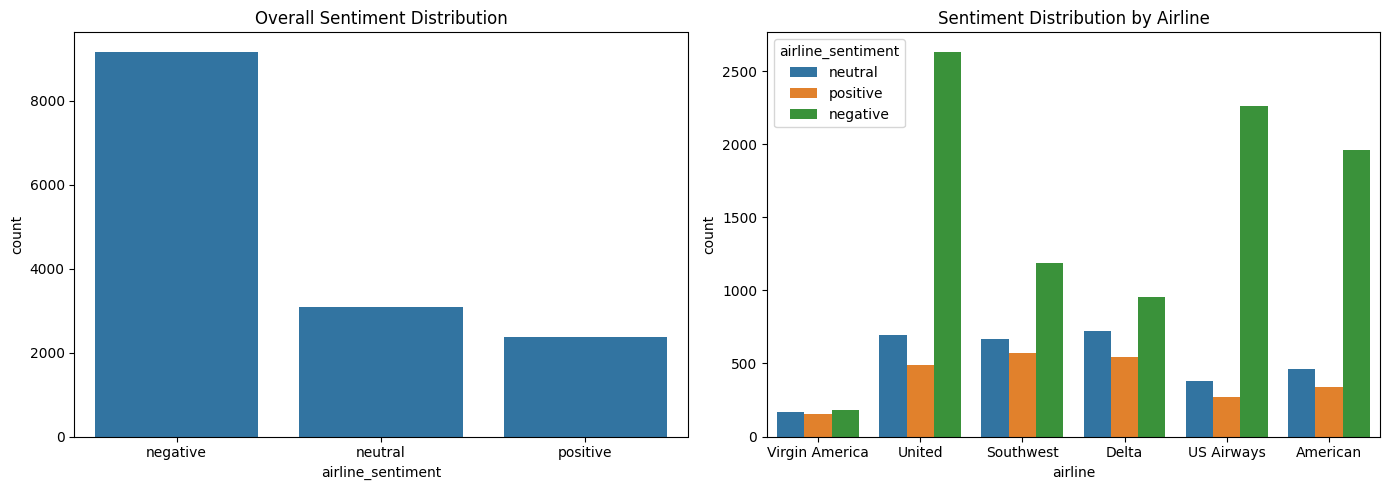

In [4]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='airline_sentiment', order=['negative', 'neutral', 'positive'])
plt.title('Overall Sentiment Distribution')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='airline', hue='airline_sentiment')
plt.title('Sentiment Distribution by Airline')

plt.tight_layout()
plt.show()

## Analysis of negative reasons

Visualizing the specific reasons for negative sentiments across different airlines.

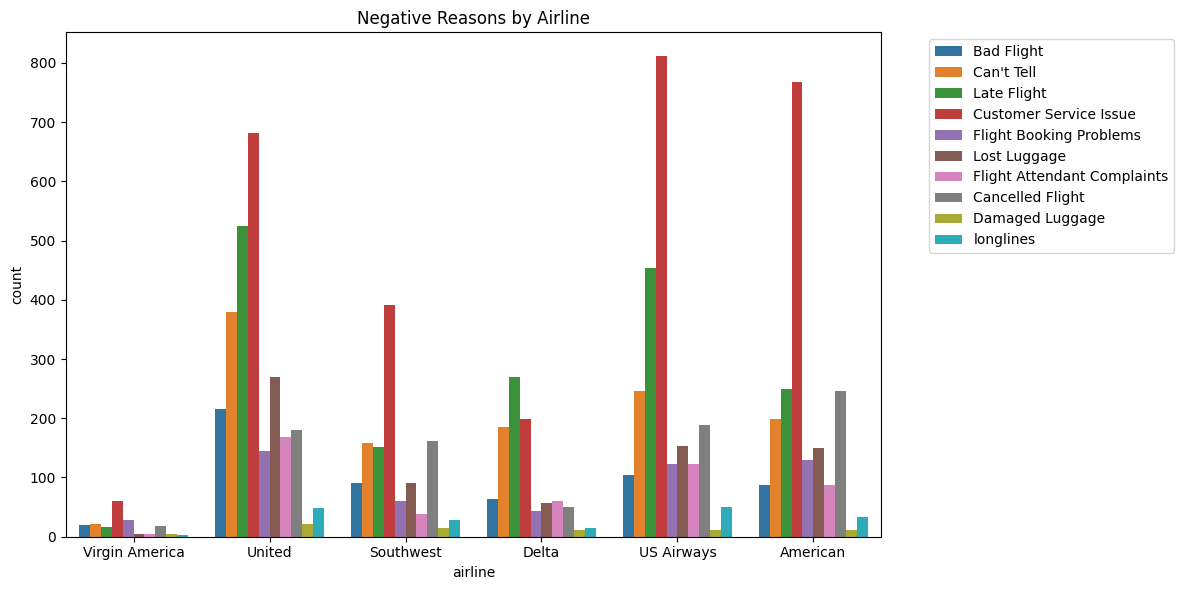

In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='airline', hue='negativereason')
plt.title('Negative Reasons by Airline')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Word clouds for sentiment categories

Generating visual representations of the most frequent words in positive and negative tweets.

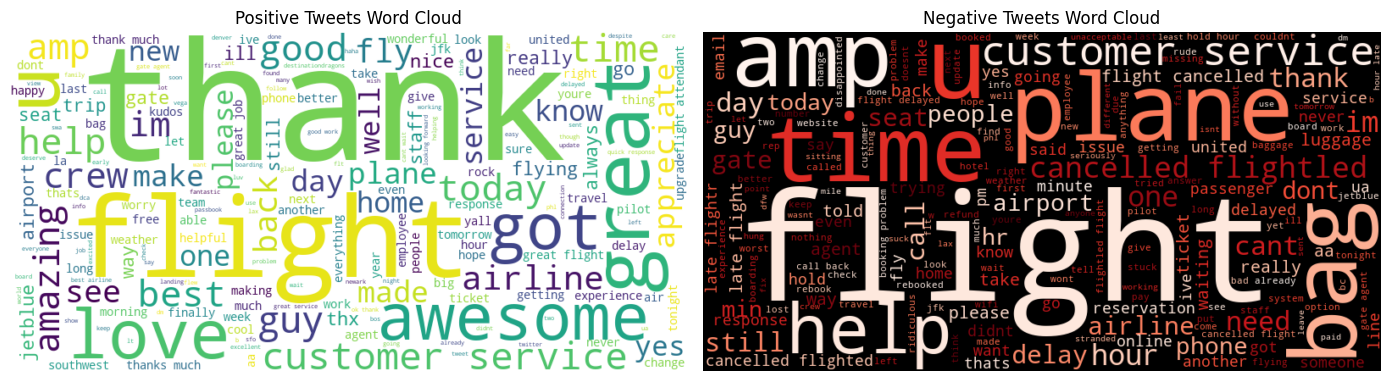

In [6]:
pos_text = ' '.join(df[df['airline_sentiment'] == 'positive']['clean_text'])
neg_text = ' '.join(df[df['airline_sentiment'] == 'negative']['clean_text'])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(pos_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Positive Tweets Word Cloud')
plt.axis('off')

plt.subplot(1, 2, 2)
wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(neg_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Negative Tweets Word Cloud')
plt.axis('off')

plt.tight_layout()
plt.show()

## Time analysis of sentiments

Tracking sentiment trends over time and identifying spikes related to specific events.

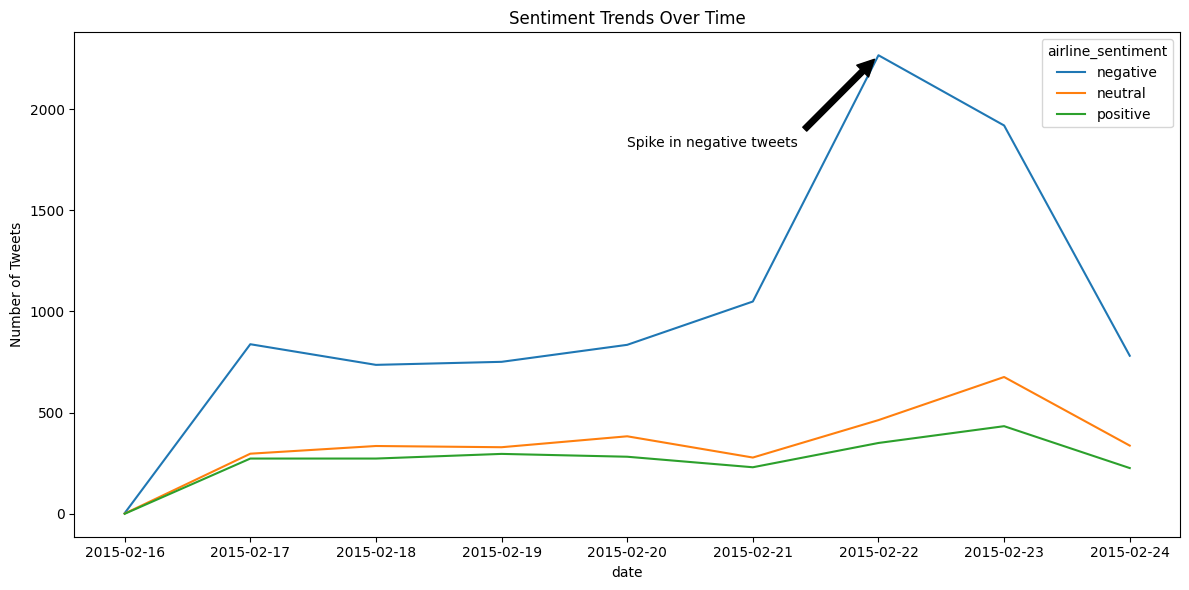

In [7]:
df['tweet_created'] = pd.to_datetime(df['tweet_created'])
df['date'] = df['tweet_created'].dt.date

daily_sentiment = df.groupby(['date', 'airline_sentiment']).size().unstack().fillna(0)

plt.figure(figsize=(12, 6))
daily_sentiment.plot(kind='line', ax=plt.gca())
plt.title('Sentiment Trends Over Time')
plt.ylabel('Number of Tweets')

target_date = pd.to_datetime('2015-02-22').date()
if target_date in daily_sentiment.index:
    plt.annotate('Spike in negative tweets',
                 xy=(target_date, daily_sentiment.loc[target_date, 'negative']),
                 xytext=(pd.to_datetime('2015-02-20').date(), daily_sentiment['negative'].max() * 0.8),
                 arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

## Sentiment analysis using VADER

Applying VADER directly to the raw text to preserve punctuation, capitalization, and emojis which amplify sentiment scores.

In [8]:
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    compound = analyzer.polarity_scores(str(text))['compound']
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    return 'neutral'

df['vader_prediction'] = df['text'].apply(get_vader_sentiment)

print("VADER Accuracy:", accuracy_score(df['airline_sentiment'], df['vader_prediction']))
print(classification_report(df['airline_sentiment'], df['vader_prediction']))

VADER Accuracy: 0.5428961748633879
              precision    recall  f1-score   support

    negative       0.90      0.50      0.64      9178
     neutral       0.38      0.43      0.41      3099
    positive       0.34      0.87      0.49      2363

    accuracy                           0.54     14640
   macro avg       0.54      0.60      0.51     14640
weighted avg       0.70      0.54      0.57     14640



## Sentiment analysis using Logistic Regression

Training a machine learning model using TF-IDF features extracted from the cleaned text.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(df['clean_text'], df['airline_sentiment'], test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
lr_predictions = model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.7991803278688525
              precision    recall  f1-score   support

    negative       0.82      0.94      0.88      1889
     neutral       0.67      0.48      0.56       580
    positive       0.82      0.61      0.70       459

    accuracy                           0.80      2928
   macro avg       0.77      0.68      0.71      2928
weighted avg       0.79      0.80      0.79      2928



## Sentiment analysis using Pre-trained Transformers

Running a HuggingFace pipeline on a small sample of the dataset to demonstrate capability without excessive computation time.

In [10]:
sentiment_pipeline = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest", max_length=512, truncation=True)

sample_df = df.sample(100, random_state=42).copy()

def get_transformer_sentiment(text):
    try:
        label = sentiment_pipeline(str(text))[0]['label'].lower()
        if label == 'neutral':
            return 'neutral'
        elif label == 'positive':
            return 'positive'
        return 'negative'
    except:
        return 'neutral'

sample_df['transformer_prediction'] = sample_df['text'].apply(get_transformer_sentiment)

print("Transformer Accuracy (Sample):", accuracy_score(sample_df['airline_sentiment'], sample_df['transformer_prediction']))
print(classification_report(sample_df['airline_sentiment'], sample_df['transformer_prediction']))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Transformer Accuracy (Sample): 0.85
              precision    recall  f1-score   support

    negative       0.93      0.87      0.90        62
     neutral       0.68      0.68      0.68        19
    positive       0.78      0.95      0.86        19

    accuracy                           0.85       100
   macro avg       0.80      0.83      0.81       100
weighted avg       0.86      0.85      0.85       100



## Conclusions

Lexicon-based methods like VADER operate best on raw text to capture emotional nuances from punctuation, but still struggle with domain-specific contexts. Logistic regression with TF-IDF provides a solid and fast baseline, while pre-trained transformers generally achieve the highest accuracy by capturing deep semantic relationships. The EDA confirmed that airline sentiment is predominantly negative, largely driven by recurring issues like customer service delays and late flights.